In [1]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo


### DA testing with GLM (Age model)

In [2]:
mdata_nk_age = mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_milo_nhoods_built.h5mu")

In [3]:
mdata_nk_age

MuData object with n_obs × n_vars = 187301 × 48457
  2 modalities
    rna:	187173 x 38606
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Sex', 'Age_years', 'Age', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Batch', 'Age_group', '_scvi_batch', '_scvi_labels', 'nhood_ixs_random', 'nhood_ixs_refined', 'nhood_kth_distance'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb'
      uns:	'Batch_colors', 'Sex_colors', '_scvi_manager_uuid', '_scvi_uuid', 'neighbors', 'nhood_neighbors_key', 'pica_cell_type_complete_01_gdT_corrected_colors', 'pool_id_colors', 'umap'
      obsm:	'X_scVI', 'X_umap', 'nhoods'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    milo:	128 x 9851
      obs:	'Age_years', 'Sex', 'Batch', 'Age', 'Age_group'
      var:	'index_cell', 'kth_di

In [4]:
milo.da_nhoods(
    mdata_nk_age,
    design="~ Batch + Sex + Age_years",
    model_contrasts="Age_years",   
    solver="pydeseq2"                  
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(
Fitting dispersions...
... done in 2.17 seconds.

Fitting MAP dispersions...
... done in 2.19 seconds.

Fitting dispersions...
... done in 2.24 seconds.

Fitting MAP dispersions...
... done in 2.24 seconds.

Fitting dispersions...
... done in 2.27 seconds.

Fitting MAP dispersions...
... done in 2.40 seconds.

Fitting dispersions...
... done in 2.28 seconds.

Fitting MAP dispersions...
... done in 2.40 seconds.

Fitting dispersions...
... done in 2.39 seconds.

Fitting MAP dispersions...
... done in 2.23 seconds.

Fitting dispersions...
... done in 2.40 seconds.

Fitting MAP dispersions...
... done in 2.22 seconds.

Fitting dispersions...
... done in 2.16 seconds.

Fitting MAP dispersions...
... done in 2.17 seconds.

Fitting dispersions.

Log2 fold change & Wald test p-value: Age_years 17.03 vs 0.05
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      2.405033       -3.108630  0.762656 -4.076058  0.000046  0.000996
1      1.031034        3.048941  0.940446  3.242015  0.001187  0.009399
2      2.242339        1.326881  0.594143  2.233269  0.025531  0.082897
3      4.291640       -2.080244  0.815015 -2.552398  0.010698  0.044928
4      2.282669        0.464959  0.493917  0.941370  0.346515  0.508949
...         ...             ...       ...       ...       ...       ...
9846   0.887164       -0.891829  0.704056 -1.266701  0.205262  0.356432
9847  11.808871       -1.231477  1.477297 -0.833602  0.404506  0.564632
9848   1.608007        1.018809  0.911325  1.117943  0.263592  0.423595
9849   1.049268        1.007157  0.631431  1.595038  0.110704  0.234434
9850   2.368651       -0.748133  0.471954 -1.585183  0.112925  0.237291

[9851 rows x 6 columns]


... done in 1.53 seconds.



In [5]:
mdata_nk_age["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [6]:
mdata_nk_age["milo"].uns

{'sample_col': 'pica_id'}

In [7]:
# Check what model_contrasts was stored
print(mdata_nk_age["milo"].uns.get("model_contrasts"))
print(mdata_nk_age["milo"].uns.get("contrast"))

None
None


In [8]:
# Check what contrast was actually used
print("Model uns:", mdata_nk_age["milo"].uns)

# Check the logFC values
print("\nlogFC head:")
print(mdata_nk_age["milo"].var["logFC"].head(10))

# Check range makes sense
print("\nlogFC range:")
print(mdata_nk_age["milo"].var["logFC"].describe())

# Check p-values are not all 1
print("\nPValue head:")
print(mdata_nk_age["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0   -3.108630
1    3.048941
2    1.326881
3   -2.080244
4    0.464959
5   -0.638516
6   -2.218825
7   -3.241764
8    1.303226
9    1.367550
Name: logFC, dtype: float64

logFC range:
count    9851.000000
mean        0.047235
std         1.531123
min        -5.241223
25%        -0.991837
50%        -0.091601
75%         0.977550
max         6.434098
Name: logFC, dtype: float64

PValue head:
0    0.000046
1    0.001187
2    0.025531
3    0.010698
4    0.346515
5    0.354114
6    0.000424
7    0.000002
8    0.205074
9    0.075248
Name: PValue, dtype: float64


In [9]:
mdata_nk_age["milo"].obs["pica_id"] = mdata_nk_age["milo"].obs.index

In [10]:
mdata_nk_age["milo"].obs["Age_group"] = pd.cut(
    mdata_nk_age["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_nk_age["milo"].obs["Age_group"] = pd.Categorical(
    mdata_nk_age["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [11]:
mdata_nk_age["milo"].obs

,Sex,Age_years,Batch,pica_id,Age_group
PICA0001,Male,2.09,Batch01,PICA0001,0-3
PICA0002,Male,15.09,Batch01,PICA0002,15-18
PICA0003,Male,0.83,Batch01,PICA0003,0-3
PICA0004,Male,1.46,Batch01,PICA0004,0-3
PICA0005,Male,9.30,Batch01,PICA0005,7-10
...,...,...,...,...,...
PICA0164,Male,2.15,Batch07,PICA0164,0-3
PICA0166,Male,0.62,Batch07,PICA0166,0-3
PICA0168,Male,16.20,Batch07,PICA0168,15-18
PICA0169,Male,2.72,Batch07,PICA0169,0-3


In [12]:
mdata_nk_age["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.457598,2.405033,-3.108630,0.000046,0.000996,0.000961
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.667299,1.031034,3.048941,0.001187,0.009399,0.009171
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.363439,2.242339,1.326881,0.025531,0.082897,0.081861
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.538970,4.291640,-2.080244,0.010698,0.044928,0.044219
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.390574,2.282669,0.464959,0.346515,0.508949,0.506993
...,...,...,...,...,...,...,...
9846,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.708672,0.887164,-0.891829,0.205262,0.356432,0.354222
9847,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,4.008997,11.808871,-1.231477,0.404506,0.564632,0.562704
9848,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.595360,1.608007,1.018809,0.263592,0.423595,0.421310
9849,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,4.445430,1.049268,1.007157,0.110704,0.234434,0.232327


In [13]:
mdata_nk_age.write_h5mu("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_age_combined_annot_with_age_nhood.h5mu")

In [14]:
mdata_nk_age["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/nk_milo_age_results.csv")

In [2]:
mdata_nk_age =mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_age_combined_annot_with_age_nhood.h5mu")

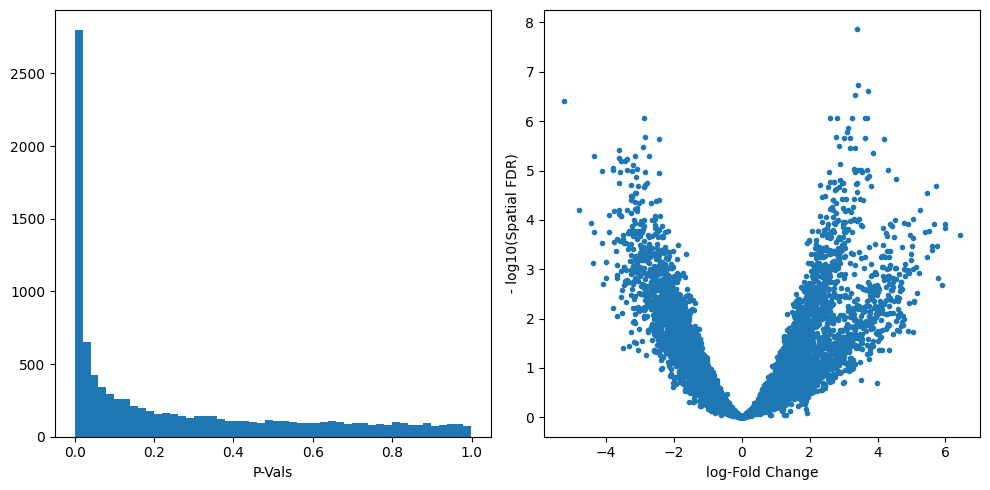

In [3]:
# QC
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_nk_age["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_nk_age["milo"].var.logFC, -np.log10(mdata_nk_age["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

<Axes: xlabel='Age_group'>

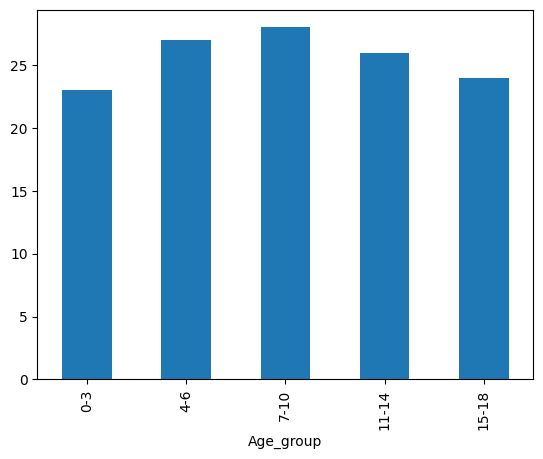

In [4]:
mdata_nk_age["milo"].obs["Age_group"].value_counts().sort_index().plot.bar()

### Visualize embedding

In [5]:
milo.build_nhood_graph(mdata_nk_age)

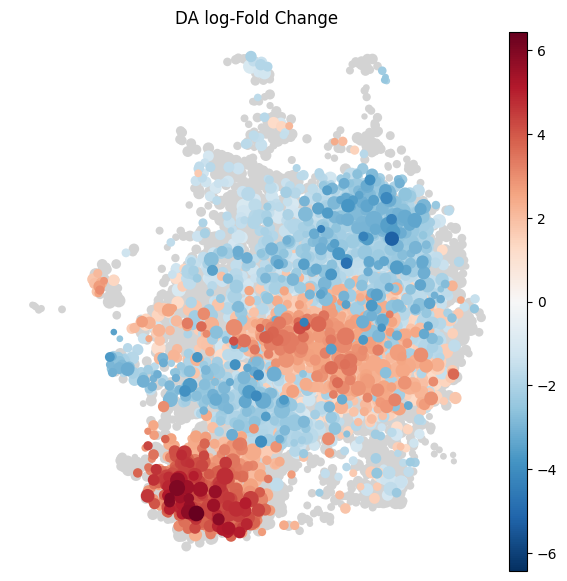

In [6]:
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_nk_age,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot, change if needed
)

### Visualize by cell type

In [7]:
milo.annotate_nhoods(mdata_nk_age, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

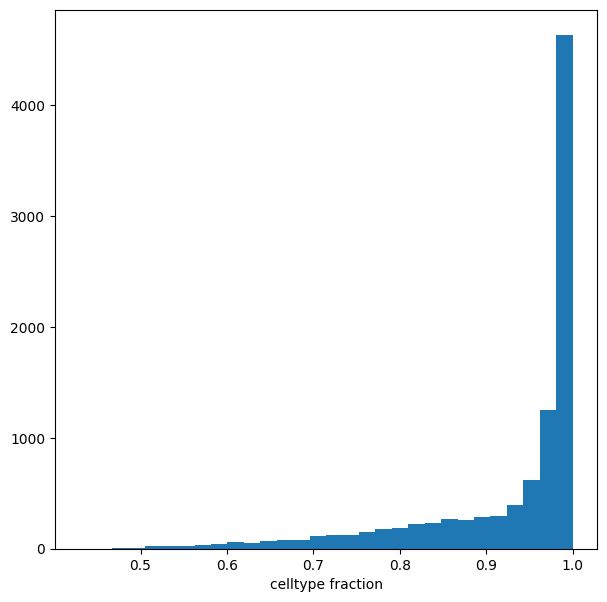

In [8]:
plt.hist(mdata_nk_age["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [9]:
mdata_nk_age["milo"].var["nhood_annotation"] = mdata_nk_age["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_nk_age["milo"].var.loc[mdata_nk_age["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1014: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nhood_adata.obs[[anno_col, "logFC"]].groupby(anno_col).median().sort_values("logFC", ascending=True).index
/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1031: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/s4575250/miniforge3/envs/BIOX7018/lib/python3.12/site-packages/pertpy/tools/_milo.py:1043: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


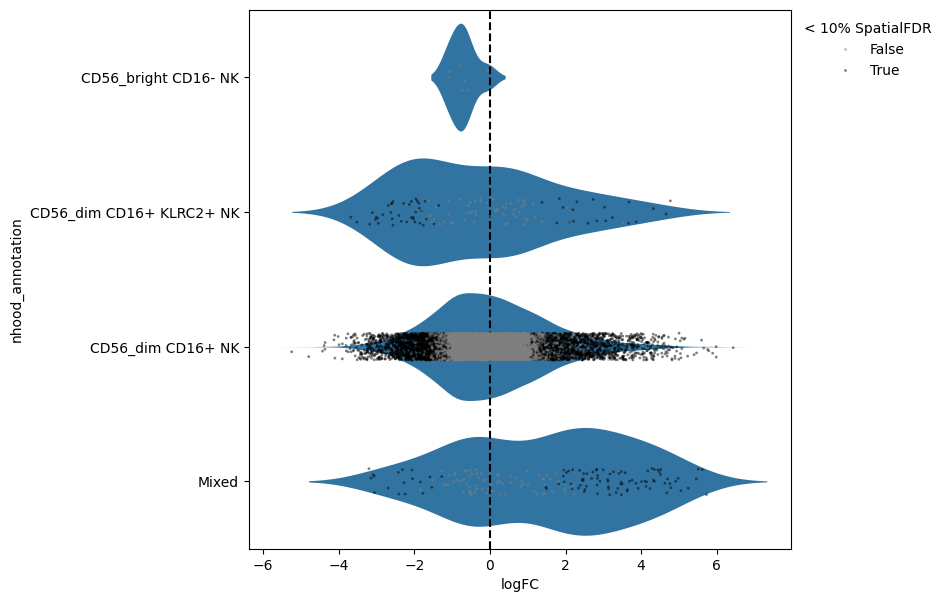

In [10]:
milo.plot_da_beeswarm(mdata_nk_age, alpha=0.1)

In [11]:
sig_nhoods_nk_age = mdata_nk_age["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_nk_age.sort_values("logFC", ascending=True).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac
4093,20250814_WGS_20250814_sc_PICA0147-PICA0173_Poo...,3.469760,3.859997,-5.241223,2.138917e-10,4.214094e-07,3.935069e-07,423.0,CD56_dim CD16+ NK,0.995272
3167,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.546345,1.694073,-4.789174,7.827994e-07,6.764348e-05,6.441437e-05,272.0,CD56_dim CD16+ NK,0.988971
3283,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.929630,0.819401,-4.427688,1.882458e-06,1.223663e-04,1.169827e-04,134.0,CD56_dim CD16+ NK,0.985075
3701,20250814_WGS_20250814_sc_PICA0147-PICA0173_Poo...,3.786411,1.391624,-4.383448,3.086962e-05,7.718187e-04,7.444947e-04,169.0,CD56_dim CD16+ NK,1.000000
3404,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,3.539757,1.834973,-4.363686,1.510611e-08,5.471714e-06,5.164395e-06,235.0,CD56_dim CD16+ NK,0.995745


In [12]:
sig_nhoods_nk_age.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/nk_sig_nhood_age_milo_results.csv")

<Axes: xlabel='logFC', ylabel='kth_distance'>

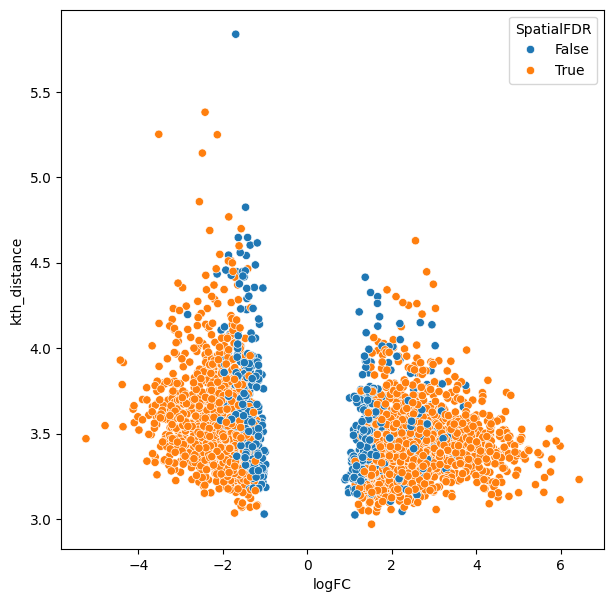

In [13]:
sns.scatterplot(
    data=sig_nhoods_nk_age,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_nk_age["SpatialFDR"] < 0.05)
)

In [14]:
pl_nhoods_nk_age = (
    mdata_nk_age["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

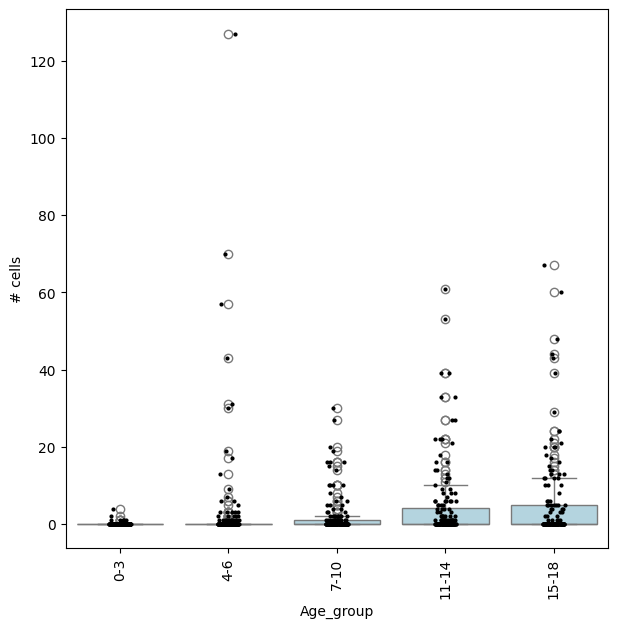

In [15]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk_age, test_var="Age_group", subset_nhoods=pl_nhoods_nk_age, log_counts=False)

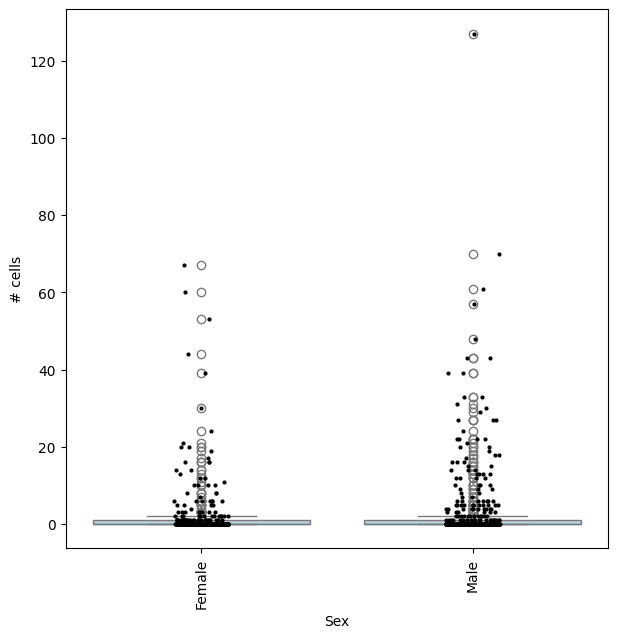

In [16]:
## Visualize cell counts by condition (x-axis) and individuals on all neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_nk_age, test_var="Sex", subset_nhoods=pl_nhoods_nk_age, log_counts=False)

/scratch/temp/24602613/ipykernel_713496/428776258.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_nk_age.groupby("nhood_annotation")["logFC"]
/scratch/temp/24602613/ipykernel_713496/428776258.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sig_df.groupby(["nhood_annotation", "direction"])


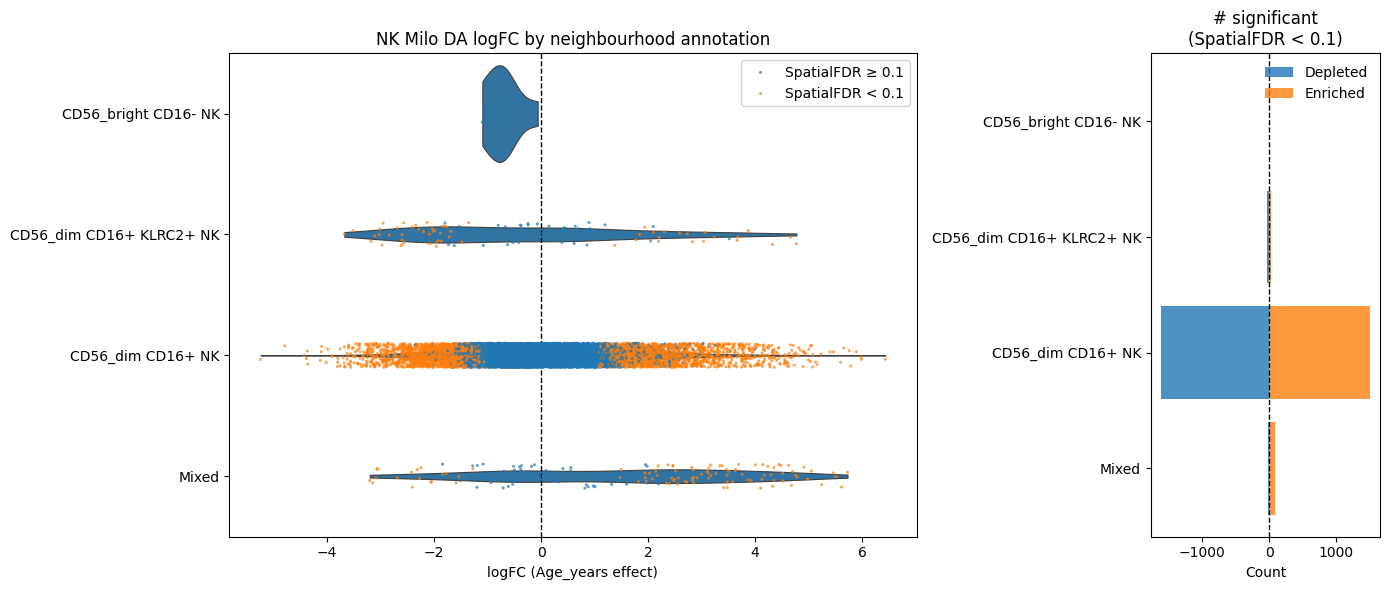

In [17]:
# full nhood results
df_nk_age = mdata_nk_age["milo"].var.copy()

# make sure the key columns exist
# df should already have: logFC, SpatialFDR, nhood_annotation
df_nk_age["sig"] = df_nk_age["SpatialFDR"] < 0.1

# (optional) order annotations by median logFC (most depleted on top)
order = (
    df_nk_age.groupby("nhood_annotation")["logFC"]
      .median()
      .sort_values()  # depleted (more negative) first
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_nk_age, y="nhood_annotation", x="logFC",
    order=order, inner=None, cut=0, linewidth=0.8, ax=axes[0]
)
sns.stripplot(
    data=df_nk_age, y="nhood_annotation", x="logFC",
    order=order, hue="sig", dodge=False, size=2.2,
    alpha=0.7, ax=axes[0]
)
axes[0].axvline(0, ls="--", c="k", lw=1)
axes[0].set_title("NK Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Age_years effect)")
axes[0].set_ylabel("")

# clean up legend (keep only one)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"], title="", loc="upper right")

# ---- Panel B: counts of significant nhoods per annotation ----
sig_df = df_nk_age[df_nk_age["sig"]].copy()

# classify direction
sig_df["direction"] = np.where(
    sig_df["logFC"] > 0,
    "Enriched",
    "Depleted"
)

# count neighbourhoods
sig_counts = (
    sig_df.groupby(["nhood_annotation", "direction"])
    .size()
    .unstack(fill_value=0)
    .reindex(order, fill_value=0)
)

# make depleted negative so bars extend left
plot_df = sig_counts.copy()

if "Depleted" in plot_df.columns:
    plot_df["Depleted"] = -plot_df["Depleted"]

# plot depleted
axes[1].barh(
    plot_df.index,
    plot_df.get("Depleted", 0),
    label="Depleted",
    alpha=0.8
)

# plot enriched
axes[1].barh(
    plot_df.index,
    plot_df.get("Enriched", 0),
    label="Enriched",
    alpha=0.8
)

# centre line
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)

axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

# keep same ordering
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order)
axes[1].invert_yaxis()

axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()